In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("Set2")

In [2]:
train_raw= pd.read_csv("data/data_set_ALL_AML_train.csv")
test_raw = pd.read_csv("data/data_set_ALL_AML_independent.csv")
labels_df = pd.read_csv("data/actual.csv")
print("--- HAM VERİ BOYUTLARI ---")
print(f"Train Seti (Satır x Sütun): {train_raw.shape}")
print(f"Test Seti  (Satır x Sütun): {test_raw.shape}")
print(f"Etiketler  (Satır x Sütun): {labels_df.shape}")

--- HAM VERİ BOYUTLARI ---
Train Seti (Satır x Sütun): (7129, 78)
Test Seti  (Satır x Sütun): (7129, 70)
Etiketler  (Satır x Sütun): (72, 2)


In [3]:
clean_train_cols = [c for c in train_raw.columns if "call" not in c]
clean_test_cols = [c for c in test_raw.columns if "call" not in c]

train_clean = train_raw[clean_train_cols]
test_clean = test_raw[clean_test_cols]

full_data = pd.merge(train_clean, test_clean, on=['Gene Description', 'Gene Accession Number'])

# C. Transpose (.T) işlemi: Genleri sütunlara, hastaları satırlara çekme
gene_ids = full_data['Gene Accession Number']
gene_data = full_data.drop(columns=['Gene Description', 'Gene Accession Number']).T

gene_data.columns = gene_ids
gene_data.index = gene_data.index.astype(int)
gene_data.sort_index(inplace=True)

# D. Kanser Etiketlerini (ALL / AML) ekleme
labels_df.set_index('patient', inplace=True)
gene_data_with_labels = gene_data.join(labels_df)

print("--- TEMİZLENMİŞ VE BİRLEŞTİRİLMİŞ VERİ MATRİSİ ---")
print(f"Toplam Hasta/Örnek Sayısı (n): {gene_data_with_labels.shape[0]}")
print(f"Toplam Özellik/Gen Sayısı (p): {gene_data_with_labels.shape[1] - 1}")
print("\nSınıf Dağılımı (Kanser Türleri):")
print(gene_data_with_labels['cancer'].value_counts())

--- TEMİZLENMİŞ VE BİRLEŞTİRİLMİŞ VERİ MATRİSİ ---
Toplam Hasta/Örnek Sayısı (n): 72
Toplam Özellik/Gen Sayısı (p): 7129

Sınıf Dağılımı (Kanser Türleri):
cancer
ALL    47
AML    25
Name: count, dtype: int64


In [4]:
missing_total = gene_data_with_labels.isnull().sum().sum()
print(f" Toplam Eksik / Missing (NaN) Değer Sayısı: {missing_total}")

gene_only = gene_data_with_labels.drop(columns=['cancer'])

print("\n=== GEN EKSPRESYON DEĞERLERİ İSTATİSTİKSEL ÖZETİ ===")
print(f"Minimum Değer : {gene_only.values.min():,.2f}")
print(f"Maksimum Değer: {gene_only.values.max():,.2f}")
print(f"Ortalama      : {gene_only.values.mean():,.2f}")
print(f"Medyan        : {np.median(gene_only.values):,.2f}")
print(f"Std Sapma     : {gene_only.values.std():,.2f}")

 Toplam Eksik / Missing (NaN) Değer Sayısı: 0

=== GEN EKSPRESYON DEĞERLERİ İSTATİSTİKSEL ÖZETİ ===
Minimum Değer : -28,400.00
Maksimum Değer: 71,369.00
Ortalama      : 619.78
Medyan        : 120.00
Std Sapma     : 2,442.06


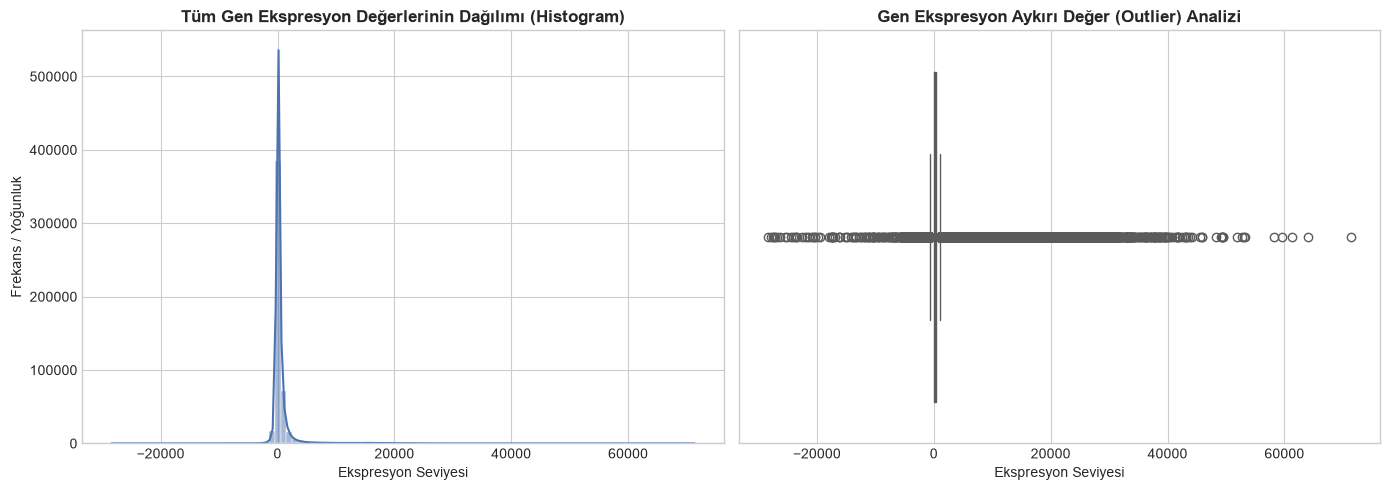

In [5]:
# Gen Ekspresyon Dağılımını ve Aykırı Değerleri Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram (Yoğunluk Dağılımı)
sns.histplot(gene_only.values.flatten(), bins=100, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Tüm Gen Ekspresyon Değerlerinin Dağılımı (Histogram)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ekspresyon Seviyesi')
axes[0].set_ylabel('Frekans / Yoğunluk')

# 2. Boxplot (Kutu Grafiği - Aykırı Değer İncelemesi)
sns.boxplot(x=gene_only.values.flatten(), ax=axes[1], color='#DD8452')
axes[1].set_title('Gen Ekspresyon Aykırı Değer (Outlier) Analizi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ekspresyon Seviyesi')

plt.tight_layout()
plt.show()

=== EN YÜKSEK VARYANSA SAHİP İLK 10 GEN ===
M25079_s_at           2.526051e+08
HG1428-HT1428_s_at    1.217362e+08
hum_alu_at            1.184315e+08
D86974_at             1.098853e+08
M26602_at             1.008080e+08
D49824_s_at           9.251405e+07
Z84721_cds2_at        7.751226e+07
L06499_at             5.896303e+07
M26311_s_at           5.033707e+07
X00274_at             4.938334e+07
dtype: float64


C:\Users\berff\AppData\Local\Temp\ipykernel_5744\2381930673.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_high_var.values, y=top_10_high_var.index, palette='Blues_r')


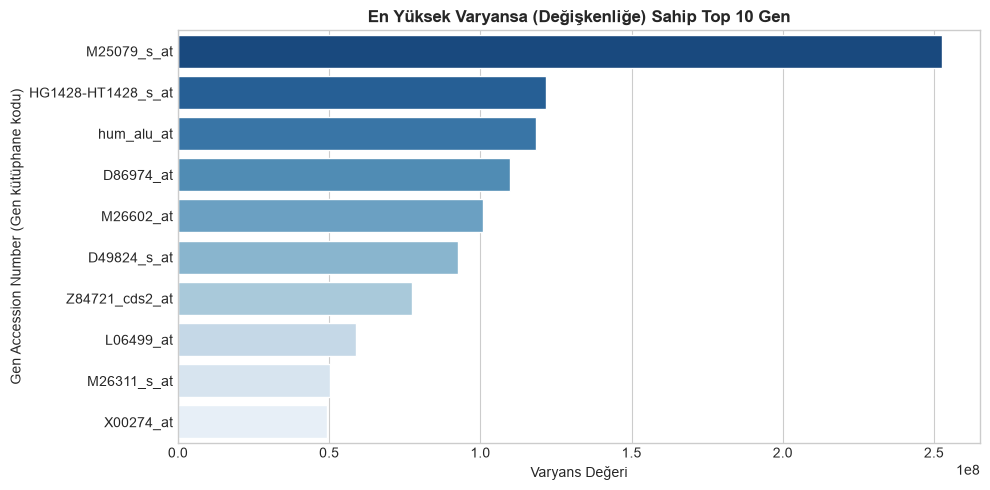

In [6]:
# 1. Her bir genin hastalar arasındaki varyansını (değişkenliğini) hesaplama
gene_variances = gene_only.var().sort_values(ascending=False)

# En yüksek varyanslı ilk 10 geni getirme
top_10_high_var = gene_variances.head(10)

print("=== EN YÜKSEK VARYANSA SAHİP İLK 10 GEN ===")
print(top_10_high_var)

# 2. Görselleştirme
plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_high_var.values, y=top_10_high_var.index, palette='Blues_r')
plt.title('En Yüksek Varyansa (Değişkenliğe) Sahip Top 10 Gen', fontsize=12, fontweight='bold')
plt.xlabel('Varyans Değeri')
plt.ylabel('Gen Accession Number (Gen kütüphane kodu)')
plt.tight_layout()
plt.show()